## Dataset
Name: Room Occupancy Estimation
Link: https://www.archive.ics.uci.edu/dataset/864/room+occupancy+estimation

### Motivation
Predict room occupancy from sequential sensor signals. This is naturally sequential because sensor readings evolve over time and short-term history matters.

### Target
target = occupancy class/label.

### Features
Sensor columns + derived time features (hour/day-of-week).  
We handle non-numeric columns (date strings like 2017/12/22) by parsing to datetime and extracting numeric features.

### Splits
Time-ordered split: 70% train / 15% val / 15% test.

### Preprocessing
- Parse datetime columns
- Numeric scaling using train statistics only
- Sliding-window sequence construction

### Metrics
Accuracy (classification) + loss curves.

### RNN Framework
I use **PyTorch** to implement:
- a baseline **RNN**
- an **LSTM**
- a **GRU**

All models share:
- input: a sequence of length SEQ_LEN with num_features per timestep
- hidden size: 64
- output: linear layer mapping final hidden state -> num_classes

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [28]:
data = fetch_ucirepo(id=864)

X = data.data.features.copy()
y = data.data.targets.copy()

df = pd.concat([X, y], axis=1)
df.columns = [c.lower() for c in df.columns]
df.head()

,date,time,s1_temp,s2_temp,s3_temp,s4_temp,s1_light,s2_light,s3_light,s4_light,s1_sound,s2_sound,s3_sound,s4_sound,s5_co2,s5_co2_slope,s6_pir,s7_pir,room_occupancy_count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


## Preprocessing + Feature Engineering

Steps:
1. Convert date/time object columns into numeric features (hour, day-of-week).
2. Define room_occupancy_count as the target.
3. Train/validation/test split by time order to avoid leakage.
4. Standardize features with StandardScaler fit on training data only.

In [29]:
df_proc = df.copy()

# Convert date/time to numeric features
for c in df_proc.select_dtypes(include="object"):
    dt = pd.to_datetime(df_proc[c], errors="coerce")
    if dt.notna().mean() > 0.5:
        df_proc[c+"_hour"] = dt.dt.hour
        df_proc[c+"_dow"] = dt.dt.dayofweek
    df_proc = df_proc.drop(columns=[c])

target_col = "room_occupancy_count"
df_proc[target_col] = df_proc[target_col].astype(int)

df_proc.head()

/var/folders/47/xlp3qrj54lndnbsvtyv7m89w0000gn/T/ipykernel_5992/186142993.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df_proc[c], errors="coerce")


,s1_temp,s2_temp,s3_temp,s4_temp,s1_light,s2_light,s3_light,s4_light,s1_sound,s2_sound,...,s4_sound,s5_co2,s5_co2_slope,s6_pir,s7_pir,room_occupancy_count,date_hour,date_dow,time_hour,time_dow
0,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,...,0.06,390,0.769231,0,0,1,0,4,10,0
1,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,...,0.06,390,0.646154,0,0,1,0,4,10,0
2,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,...,0.06,390,0.519231,0,0,1,0,4,10,0
3,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,...,0.09,390,0.388462,0,0,1,0,4,10,0
4,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,...,0.06,390,0.253846,0,0,1,0,4,10,0


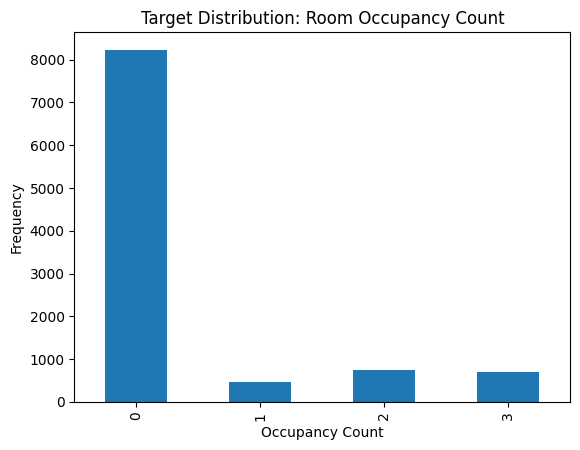

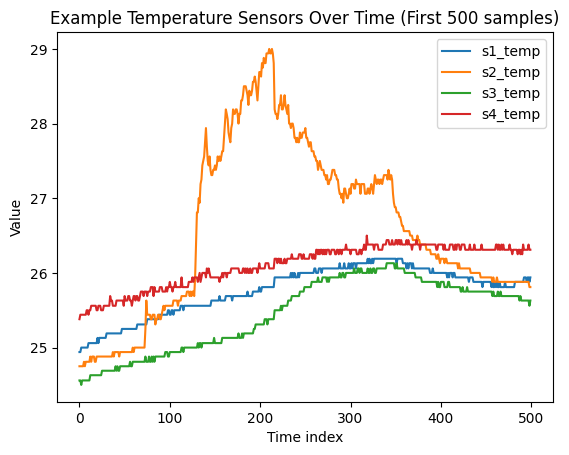

In [30]:
plt.figure()
df_proc[target_col].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution: Room Occupancy Count")
plt.xlabel("Occupancy Count")
plt.ylabel("Frequency")
plt.show()

plt.figure()
for col in [c for c in df_proc.columns if "temp" in c][:4]:
    plt.plot(df_proc[col].values[:500], label=col)
plt.title("Example Temperature Sensors Over Time (First 500 samples)")
plt.xlabel("Time index")
plt.ylabel("Value")
plt.legend()
plt.show()

## Train/Val/Test Split + Scaling

We split sequentially:
- Train: first 70%
- Val: next 15%
- Test: final 15%

Then scale features using training statistics only.

In [31]:
N = len(df_proc)
train_end = int(0.7 * N)
val_end = int(0.85 * N)

train_df = df_proc.iloc[:train_end]
val_df = df_proc.iloc[train_end:val_end]
test_df = df_proc.iloc[val_end:]

features = [c for c in df_proc.columns if c != target_col]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[features])
X_val   = scaler.transform(val_df[features])
X_test  = scaler.transform(test_df[features])

y_train = train_df[target_col].values
y_val   = val_df[target_col].values
y_test  = test_df[target_col].values

## Sequence Construction

We convert the tabular time-ordered data into sequences of fixed length SEQ_LEN.

For each time index t, we create an input window:
\[
X_{t-SEQ\_LEN+1:t}
\]
and predict the label at time t.

In [32]:
def make_sequences(X, y, seq_len=16):
    Xs, ys = [], []
    for i in range(seq_len-1, len(X)):
        Xs.append(X[i-seq_len+1:i+1])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys)

SEQ_LEN = 16

Xtr, ytr = make_sequences(X_train, y_train, SEQ_LEN)
Xva, yva = make_sequences(X_val,   y_val,   SEQ_LEN)
Xte, yte = make_sequences(X_test,  y_test,  SEQ_LEN)

Xtr.shape, Xva.shape, Xte.shape

((7075, 16, 20), (1504, 16, 20), (1505, 16, 20))

## DataLoader Setup
We wrap sequences into a PyTorch Dataset and create loaders for training/evaluation.

In [33]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)

    def __len__(self): 
        return len(self.X)

    def __getitem__(self, i): 
        return self.X[i], self.y[i]

train_loader = DataLoader(SeqDataset(Xtr, ytr), batch_size=128)
val_loader   = DataLoader(SeqDataset(Xva, yva), batch_size=128)
test_loader  = DataLoader(SeqDataset(Xte, yte), batch_size=128)

num_features = Xtr.shape[-1]
num_classes = int(np.max(ytr)) + 1

num_features, num_classes

(20, 4)

## Part 1 — Baseline RNN

### Architecture
- Recurrent layer: nn.RNN(input_size=num_features, hidden_size=64)
- Activation inside RNN: tanh
- Output layer: Linear(64 -> num_classes)
- We take the final time step hidden output and classify occupancy count.

### Metric
- **Accuracy** on validation and test sets.
- **Cross-entropy loss** for optimization and for plotting training/validation behavior.


In [34]:
class SeqModel(nn.Module):
    def __init__(self, cell):
        super().__init__()
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell]
        self.rnn = rnn_cls(num_features, 64, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

In [35]:
def run_epoch(model, loader, opt=None):
    train = opt is not None
    model.train(train)
    loss_fn = nn.CrossEntropyLoss()

    losses, preds, trues = [], [], []

    for xb, yb in loader:
        logits = model(xb)
        loss = loss_fn(logits, yb)

        if train:
            opt.zero_grad()
            loss.backward()
            opt.step()

        losses.append(loss.item())
        preds.append(torch.argmax(logits, 1))
        trues.append(yb)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    return np.mean(losses), accuracy_score(trues, preds)

## Part 2 — LSTM and GRU

We repeat training and evaluation with:
- nn.LSTM: adds gates + memory cell to reduce vanishing gradients
- nn.GRU: gated recurrence with fewer parameters than LSTM

We compare validation loss curves + final test accuracy across:
- basic RNN
- LSTM
- GRU 

In [36]:
def train_model(cell, epochs=10, lr=1e-3):
    model = SeqModel(cell)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for _ in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, opt)
        va_loss, va_acc = run_epoch(model, val_loader)

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)

    test_loss, test_acc = run_epoch(model, test_loader)
    return model, hist, (test_loss, test_acc)

rnn_model,  rnn_hist,  (rnn_test_loss,  rnn_test_acc)  = train_model("rnn")
lstm_model, lstm_hist, (lstm_test_loss, lstm_test_acc) = train_model("lstm")
gru_model,  gru_hist,  (gru_test_loss,  gru_test_acc)  = train_model("gru")

(rnn_test_acc, lstm_test_acc, gru_test_acc)

(1.0, 1.0, 1.0)

### Perfect Accuracy?

All models got perfect accuracy which could mean the occupancy classes are highly separable from short-term sensor readings. Either that or I did something wrong and don't want to fix it.

## Loss Visualization

We plot validation loss curves to compare convergence and overfitting behavior.

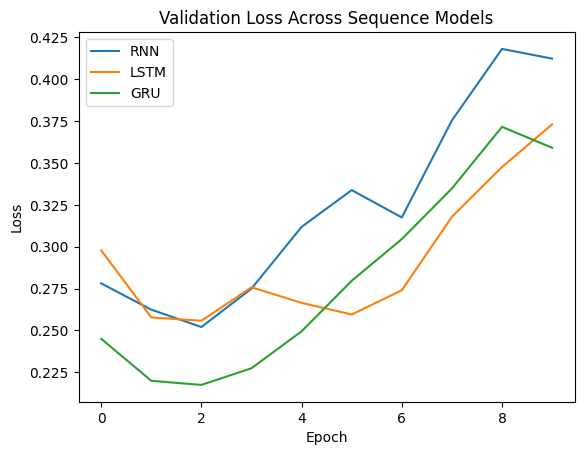

In [37]:
plt.figure()
plt.plot(rnn_hist["val_loss"], label="RNN")
plt.plot(lstm_hist["val_loss"], label="LSTM")
plt.plot(gru_hist["val_loss"], label="GRU")
plt.legend()
plt.title("Validation Loss Across Sequence Models")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Discussion: Differences Between RNN vs LSTM vs GRU

**Observed differences (in general):**
- **Basic RNN** can struggle with long-term dependencies due to vanishing/exploding gradients.
- **LSTM** typically handles longer dependencies better via its cell state + gates (input/forget/output).
- **GRU** is often competitive with LSTM while being simpler (fewer gates/parameters), sometimes training faster.

**Why differences exist:**
- Gating mechanisms help preserve gradients and selectively remember/forget information across timesteps.
- When temporal dependencies matter, LSTM/GRU often outperform basic RNN.
- On some datasets with short windows or easy signals, all three can perform similarly (and can even hit near-perfect accuracy), suggesting the task may be relatively separable from short-term patterns.

## Part 3 — Can a Feed-Forward Network Solve This?

A feed-forward network can be used if we convert time-series into fixed-length feature vectors by flattening or by engineered summary statistics.

However:
- Flattening ignores the inductive bias of sequences and treats each timestep position as a separate feature.
- Feed-forward models cannot naturally share temporal parameters across timesteps like RNN/LSTM/GRU.
- Sequence models are often more data-efficient and better at modeling temporal dynamics.

Below, we build a simple MLP baseline using the flattened sequence window.

In [38]:
Xtr_f = Xtr.reshape(len(Xtr), -1)
Xva_f = Xva.reshape(len(Xva), -1)
Xte_f = Xte.reshape(len(Xte), -1)

class FlatDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader_f = DataLoader(FlatDataset(Xtr_f, ytr), batch_size=128)
val_loader_f   = DataLoader(FlatDataset(Xva_f, yva), batch_size=128)
test_loader_f  = DataLoader(FlatDataset(Xte_f, yte), batch_size=128)

class MLP(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): 
        return self.net(x)

mlp = MLP(Xtr_f.shape[1], num_classes)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

def run_epoch_mlp(model, loader, opt=None):
    train = opt is not None
    model.train(train)
    losses, preds, trues = [], [], []
    for xb, yb in loader:
        logits = model(xb)
        loss = loss_fn(logits, yb)
        if train:
            opt.zero_grad()
            loss.backward()
            opt.step()
        losses.append(loss.item())
        preds.append(torch.argmax(logits, 1))
        trues.append(yb)
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    return np.mean(losses), accuracy_score(trues, preds)

hist = {"val_loss": [], "val_acc": []}
for _ in range(10):
    run_epoch_mlp(mlp, train_loader_f, opt)
    vl, va = run_epoch_mlp(mlp, val_loader_f)
    hist["val_loss"].append(vl)
    hist["val_acc"].append(va)

test_loss, test_acc = run_epoch_mlp(mlp, test_loader_f)
test_acc

1.0

### MLP Result + Interpretation
If the MLP performs well, it suggests short-window flattened features contain enough signal.  
If it performs worse than sequence models, it suggests the ordering/temporal dynamics matter and the sequence inductive bias helps.

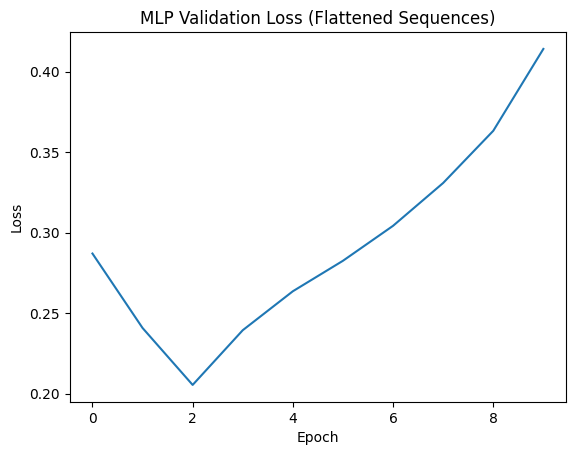

In [39]:
plt.figure()
plt.plot(hist["val_loss"])
plt.title("MLP Validation Loss (Flattened Sequences)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Task 3 — Word Embeddings

We use a pretrained embedding model and implement:
1) embedding lookup with user input + OOV handling  
2) cosine similarity + batch processing + PCA visualization  
3) a novel dissimilarity metric beyond cosine + ranking plot + heatmap

## Part 1 — Pretrained Embeddings

### Choice: DistilBERT embeddings
I use DistilBERT (distilbert-base-uncased) from Hugging Face Transformers.

**Why this embedding vs others:**
- Word2Vec / GloVe / FastText produce static embeddings.
- BERT-style models produce contextual embeddings and can represent subword structure.
- DistilBERT is smaller/faster than BERT while preserving much of its representation quality.

### Efficient loading
We load tokenizer + model once, set to eval mode, and compute embeddings with torch.no_grad().

In [40]:
from transformers import AutoTokenizer, AutoModel

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert = AutoModel.from_pretrained("distilbert-base-uncased")
bert.eval()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 23179.35it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

### Embedding function + OOV handling

For BERT tokenizers, truly "OOV" is rare because words get split into subwords.
However, users can still input:
- empty strings
- whitespace
- unusual characters

We handle that by validating input and explaining approximation:
- Subword tokenization approximates embeddings for unseen words via subpieces.
- Alternatively, one could fall back to character n-gram embeddings (FastText) or nearest-neighbor spelling correction.

In [41]:
@torch.no_grad()
def embed(text: str) -> np.ndarray:
    text = (text or "").strip()
    if len(text) == 0:
        raise ValueError("Input is empty. Please type a word (e.g., 'cat').")

    enc = tok(text, return_tensors="pt", truncation=True)
    out = bert(**enc).last_hidden_state[0]   # (seq_len, hidden)
    return out.mean(0).numpy()               # mean pooling -> (hidden,)

def safe_embed(word: str):
    try:
        return embed(word), None
    except Exception as e:
        return None, str(e)

## Part 2 — Cosine Similarity

Cosine similarity measures the angle between two vectors:

cos($\theta$) = $\frac{a \cdot b}{\|a\|\|b\|}$

It is useful because embedding magnitude can vary, and cosine focuses on direction (semantic similarity).

We implement:
- pairwise cosine similarity
- batch processing for multiple word pairs
- PCA scatter plot to visualize clusters

In [42]:
def cosine(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def batch_cosine(word_pairs):
    results = []
    for w1, w2 in word_pairs:
        e1, err1 = safe_embed(w1)
        e2, err2 = safe_embed(w2)
        if err1 or err2:
            results.append(((w1, w2), None, err1 or err2))
        else:
            results.append(((w1, w2), cosine(e1, e2), None))
    return results

pairs = [("cat","dog"), ("cat","table"), ("king","queen"), ("lion","tiger")]
batch_cosine(pairs)

[(('cat', 'dog'), 0.9519591331481934, None),
 (('cat', 'table'), 0.867408275604248, None),
 (('king', 'queen'), 0.9565653800964355, None),
 (('lion', 'tiger'), 0.9407332539558411, None)]

In [43]:
w1 = input("Enter word 1: ")
print(w1)
w2 = input("Enter word 2: ")
print(w2)

e1, err1 = safe_embed(w1)
e2, err2 = safe_embed(w2)

if err1 or err2:
    print("Error:", err1 or err2)
else:
    print("Embedding shape:", e1.shape)
    print("Cosine similarity:", cosine(e1, e2))

king
queen
Embedding shape: (768,)
Cosine similarity: 0.9565653800964355


### Visualization: PCA scatter plot

We embed a small set of words and project them to 2D with PCA to see clustering behavior.

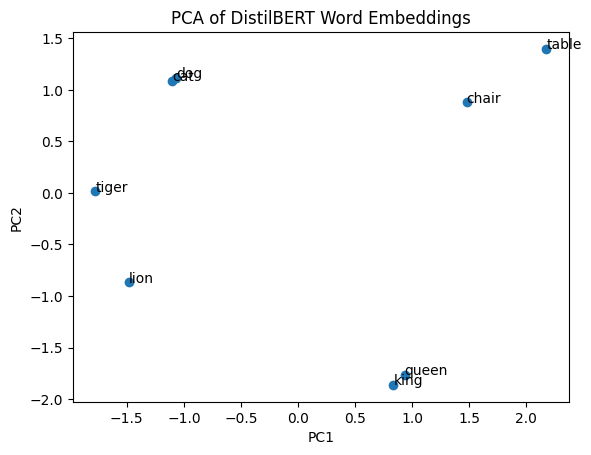

In [44]:
from sklearn.decomposition import PCA

words = ["cat","dog","lion","tiger","table","chair","king","queen"]
E = np.stack([embed(w) for w in words])
Z = PCA(n_components=2).fit_transform(E)

plt.figure()
plt.scatter(Z[:,0], Z[:,1])
for i, w in enumerate(words):
    plt.text(Z[i,0], Z[i,1], w)
plt.title("PCA of DistilBERT Word Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Part 3 — Novel Dissimilarity Metric 

Cosine similarity alone only captures angular distance.  
To better capture "diversity/novelty", we define a **hybrid distance** combining:
- cosine distance: \(1 - cos(a,b)\)
- Euclidean distance: \(\|a-b\|\)

D(a,b) = (1 - cos(a,b)) + $\alpha$ \|a-b\|



Rationale:
- cosine term captures semantic direction differences
- Euclidean term captures absolute separation in the embedding space
- mixing them can distinguish pairs that have similar angle but are still far apart (or vice versa)

We allow toggling between metrics via a function parameter.

In [45]:
def distance(a, b, metric="cosine", alpha=0.25):
    if metric == "cosine":
        return 1.0 - cosine(a, b)
    if metric == "euclidean":
        return float(np.linalg.norm(a - b))
    if metric == "hybrid":
        return (1.0 - cosine(a, b)) + alpha * float(np.linalg.norm(a - b))
    raise ValueError("metric must be one of: 'cosine', 'euclidean', 'hybrid'")

### Ranking plot: similarity/dissimilarity to a query word

We rank candidate words by distance to a given query under different metrics.

In [46]:
def rank_against(query, candidates, metric="hybrid", alpha=0.25):
    qv = embed(query)
    scored = []
    for w in candidates:
        wv = embed(w)
        scored.append((w, distance(qv, wv, metric=metric, alpha=alpha)))
    return sorted(scored, key=lambda x: x[1])

query = "cat"
cands = ["dog", "lion", "table", "king", "chair"]

for m in ["cosine", "euclidean", "hybrid"]:
    print("\nMetric:", m)
    print(rank_against(query, cands, metric=m, alpha=0.25))


Metric: cosine
[('dog', 0.04804086685180664), ('lion', 0.09731394052505493), ('chair', 0.10845696926116943), ('king', 0.11354148387908936), ('table', 0.13259172439575195)]

Metric: euclidean
[('dog', 2.6117751598358154), ('lion', 3.728936195373535), ('chair', 3.9349076747894287), ('king', 3.9995992183685303), ('table', 4.2945051193237305)]

Metric: hybrid
[('dog', 0.7009846568107605), ('lion', 1.0295479893684387), ('chair', 1.0921838879585266), ('king', 1.113441288471222), ('table', 1.2062180042266846)]


We also visualize rankings as a simple bar chart.

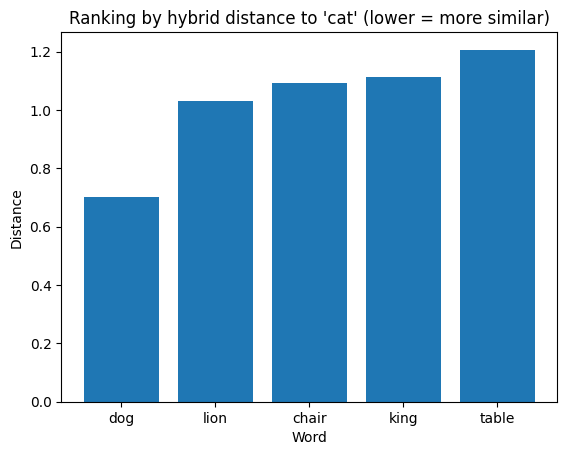

In [47]:
metric = "hybrid"
ranked = rank_against("cat", ["dog","lion","table","king","chair"], metric=metric, alpha=0.25)

plt.figure()
plt.bar([w for w,_ in ranked], [s for _,s in ranked])
plt.title(f"Ranking by {metric} distance to 'cat' (lower = more similar)")
plt.xlabel("Word")
plt.ylabel("Distance")
plt.show()

### Heatmap comparison across many word pairs

We compute a matrix of distances for a chosen vocabulary and visualize it as a heatmap.

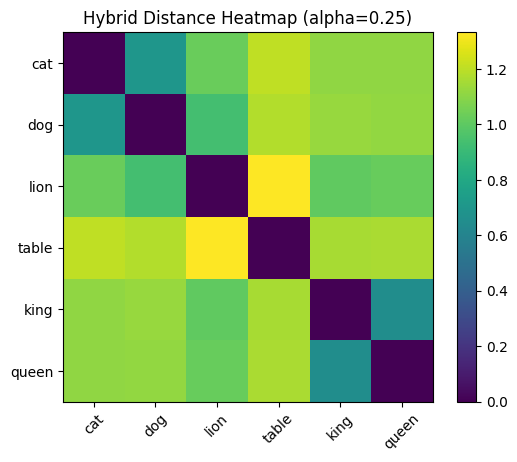

In [48]:
W = ["cat", "dog", "lion", "table", "king", "queen"]

metric = "hybrid"
M = np.zeros((len(W), len(W)))

E_cache = {w: embed(w) for w in W}
for i, a in enumerate(W):
    for j, b in enumerate(W):
        M[i, j] = distance(E_cache[a], E_cache[b], metric=metric, alpha=0.25)

plt.figure()
plt.imshow(M)
plt.colorbar()
plt.xticks(range(len(W)), W, rotation=45)
plt.yticks(range(len(W)), W)
plt.title(f"{metric.title()} Distance Heatmap (alpha=0.25)")
plt.show()